In [1]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential, Model
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPool2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.datasets.fashion_mnist import load_data
from keras.utils import to_categorical
from keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing.image import load_img, img_to_array

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'

In [2]:
modelVgg = VGG16(include_top=False, input_shape=(100,100,3)) # include_top=False -> 분류기 사용 X, 특징 추출기만 있는 층을 가져옴, 분류기는 추가 학습 
modelVgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
modelVgg.layers # 각 층에 있는 object 확인 가능

[<InputLayer name=input_layer, built=True>,
 <Conv2D name=block1_conv1, built=True>,
 <Conv2D name=block1_conv2, built=True>,
 <MaxPooling2D name=block1_pool, built=True>,
 <Conv2D name=block2_conv1, built=True>,
 <Conv2D name=block2_conv2, built=True>,
 <MaxPooling2D name=block2_pool, built=True>,
 <Conv2D name=block3_conv1, built=True>,
 <Conv2D name=block3_conv2, built=True>,
 <Conv2D name=block3_conv3, built=True>,
 <MaxPooling2D name=block3_pool, built=True>,
 <Conv2D name=block4_conv1, built=True>,
 <Conv2D name=block4_conv2, built=True>,
 <Conv2D name=block4_conv3, built=True>,
 <MaxPooling2D name=block4_pool, built=True>,
 <Conv2D name=block5_conv1, built=True>,
 <Conv2D name=block5_conv2, built=True>,
 <Conv2D name=block5_conv3, built=True>,
 <MaxPooling2D name=block5_pool, built=True>]

In [4]:
len(modelVgg.layers)

19

---

특징 추출기 고정 + 새 분류기 학습

In [5]:
# # 모든 층을 학습에 포함 X
# for layer in modelVgg.layers:
#     layer.trainable = False # modelVgg을 학습에서 제외 시킴

---

일부 Conv 층 + 분류기 재학습 

In [6]:
# # 특정 추출기의 마지막 4개의 층은 학습에 포함 시킴
# for layer in modelVgg.layers[:-4]: # 뒤에서 4번째까지만 학습
#     layer.trainable = False # modelVgg을 학습에서 제외 시킴

In [7]:
dataGen = ImageDataGenerator(rescale=1./255)
imageGen = dataGen.flow_from_directory('./cat_dog', target_size=(100,100))

model = Sequential()
model.add( modelVgg )
model.add( Flatten())
model.add( Dense(units=64, activation='relu') )
model.add( Dense(units=2, activation='softmax') )
model.compile( loss='categorical_crossentropy', optimizer='adam', metrics=['acc'] )
model.fit( imageGen, epochs=100 )

Found 20 images belonging to 2 classes.


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - acc: 0.5000 - loss: 0.7458
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step - acc: 0.5000 - loss: 21.0559
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step - acc: 0.5000 - loss: 2.1562
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step - acc: 0.5000 - loss: 0.7472
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step - acc: 0.5000 - loss: 1.6715
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step - acc: 0.5000 - loss: 2.5435
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step - acc: 0.5000 - loss: 1.5383
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step - acc: 0.5000 - loss: 0.8259
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step - acc: 0.5000 - loss: 0.7071
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 586ms/step - acc: 0.5000 - loss: 1.0145
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step - acc: 0.5000 - loss: 0.7097
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step - acc: 0.5000 - loss: 0.7346
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,029,384 (171.77 MB)

 Trainable params: 15,009,794 (57.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,019,590 (114.52 MB)

In [9]:
imageGen.class_indices # 모델이 사용하는 실제 정답 숫자 기준표

{'cat': 0, 'dog': 1}

In [10]:
img = load_img('./image/cat.jpg', target_size=(100,100))
carr = img_to_array(img)/255
model.predict(carr.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


array([1])

### 퀴즈 : shape 전이학습

In [11]:
# dataGen = ImageDataGenerator( rescale= 1. / 255 )
dataGen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, vertical_flip=True, 
                            shear_range=0.5, 
                            brightness_range=[0.5,1.5], zoom_range=0.2,
                            width_shift_range=0.1, height_shift_range=0.1,
                            rotation_range=30, fill_mode='nearest' )
imageGen = dataGen.flow_from_directory('./shapes', target_size=(100,100))

Found 14970 images belonging to 4 classes.


In [12]:
model = Sequential()
model.add( modelVgg )
model.add( Flatten())
model.add( Dense(units=64, activation='relu') )
model.add( Dense(units=4, activation='softmax') )
model.compile( loss='categorical_crossentropy', optimizer='adam', metrics=['acc'] )
model.fit( imageGen, epochs=5 )

Epoch 1/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 521s 1s/step - acc: 0.6416 - loss: 0.7327
Epoch 2/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 533s 1s/step - acc: 0.9822 - loss: 0.0607
Epoch 3/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 520s 1s/step - acc: 0.9719 - loss: 0.1220
Epoch 4/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 524s 1s/step - acc: 0.9902 - loss: 0.0412
Epoch 5/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 516s 1s/step - acc: 0.9985 - loss: 0.0054


In [13]:
model.layers

[<Functional name=vgg16, built=True>,
 <Flatten name=flatten_1, built=True>,
 <Dense name=dense_2, built=True>,
 <Dense name=dense_3, built=True>]

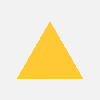

In [14]:
triangleimg = load_img('C:/deepTest/image/triangle.png',target_size=(100,100))
triangleimg

In [15]:
imgArr = img_to_array(triangleimg)/255
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


array([3])

In [16]:
imageGen.class_indices


{'circle': 0, 'square': 1, 'star': 2, 'triangle': 3}